In [24]:
# Install required packages
!pip install boto3 s3fs mlflow xgboost -q

print("Packages installed successfully")

Packages installed successfully


In [25]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# AWS
import boto3
import io

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Utilities
import warnings
import time
from math import radians, sin, cos, sqrt, atan2

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [26]:
# Load dataset
df_raw = pd.read_csv('AB_NYC_2019.csv')

print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nFirst 3 rows:")
display(df_raw.head(3))

Dataset loaded: 48,895 rows × 16 columns

Columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

First 3 rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365


In [27]:
# Dataset information
print("Dataset Information:")
print("="*60)
df_raw.info()

print("Missing Values Analysis:")
print("="*60)
missing = df_raw.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    for col, count in missing.items():
        print(f"  • {col}: {count:,} ({count/len(df_raw)*100:.1f}%)")
else:
    print("  No missing values detected")

print("Target Variable: price")
print("="*60)
print(f"  Mean: ${df_raw['price'].mean():.2f}")
print(f"  Median: ${df_raw['price'].median():.2f}")
print(f"  Min: ${df_raw['price'].min():.0f}")
print(f"  Max: ${df_raw['price'].max():.0f}")
print(f"  Std Dev: ${df_raw['price'].std():.2f}")
print(f"\nAnomalies:")
print(f"  • Price = $0: {(df_raw['price'] == 0).sum()} listings")
print(f"  • Price > $1000: {(df_raw['price'] > 1000).sum()} listings")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review

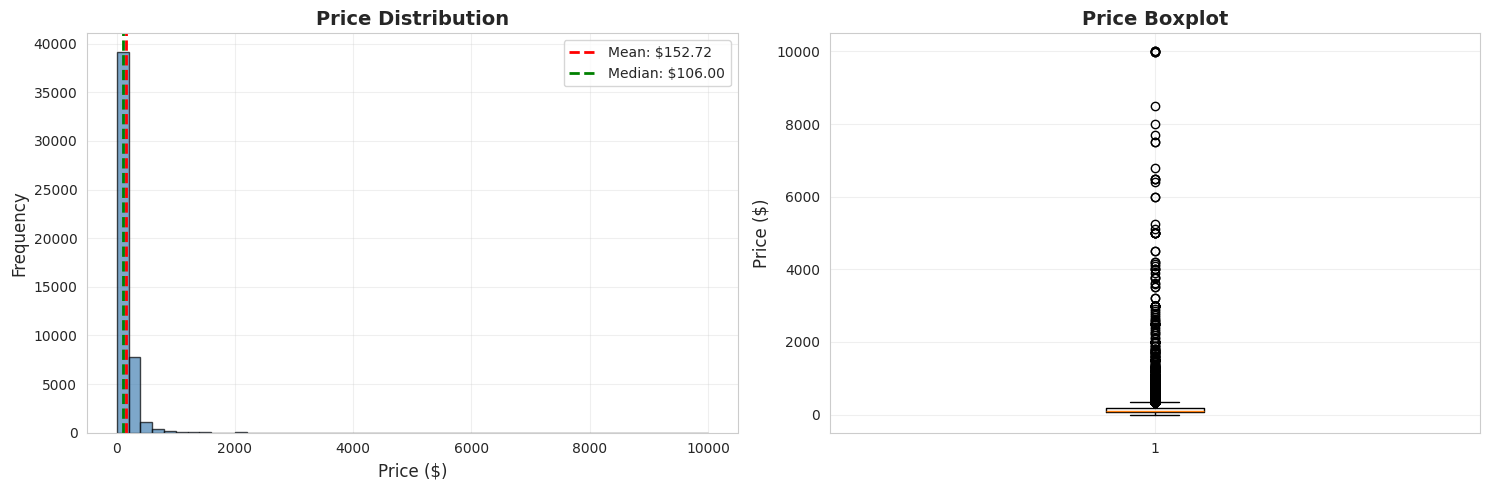

In [28]:
# Price distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_raw['price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df_raw['price'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: ${df_raw["price"].mean():.2f}')
axes[0].axvline(df_raw['price'].median(), color='green', linestyle='--', linewidth=2,
                label=f'Median: ${df_raw["price"].median():.2f}')
axes[0].set_xlabel('Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(df_raw['price'], vert=True)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].set_title('Price Boxplot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

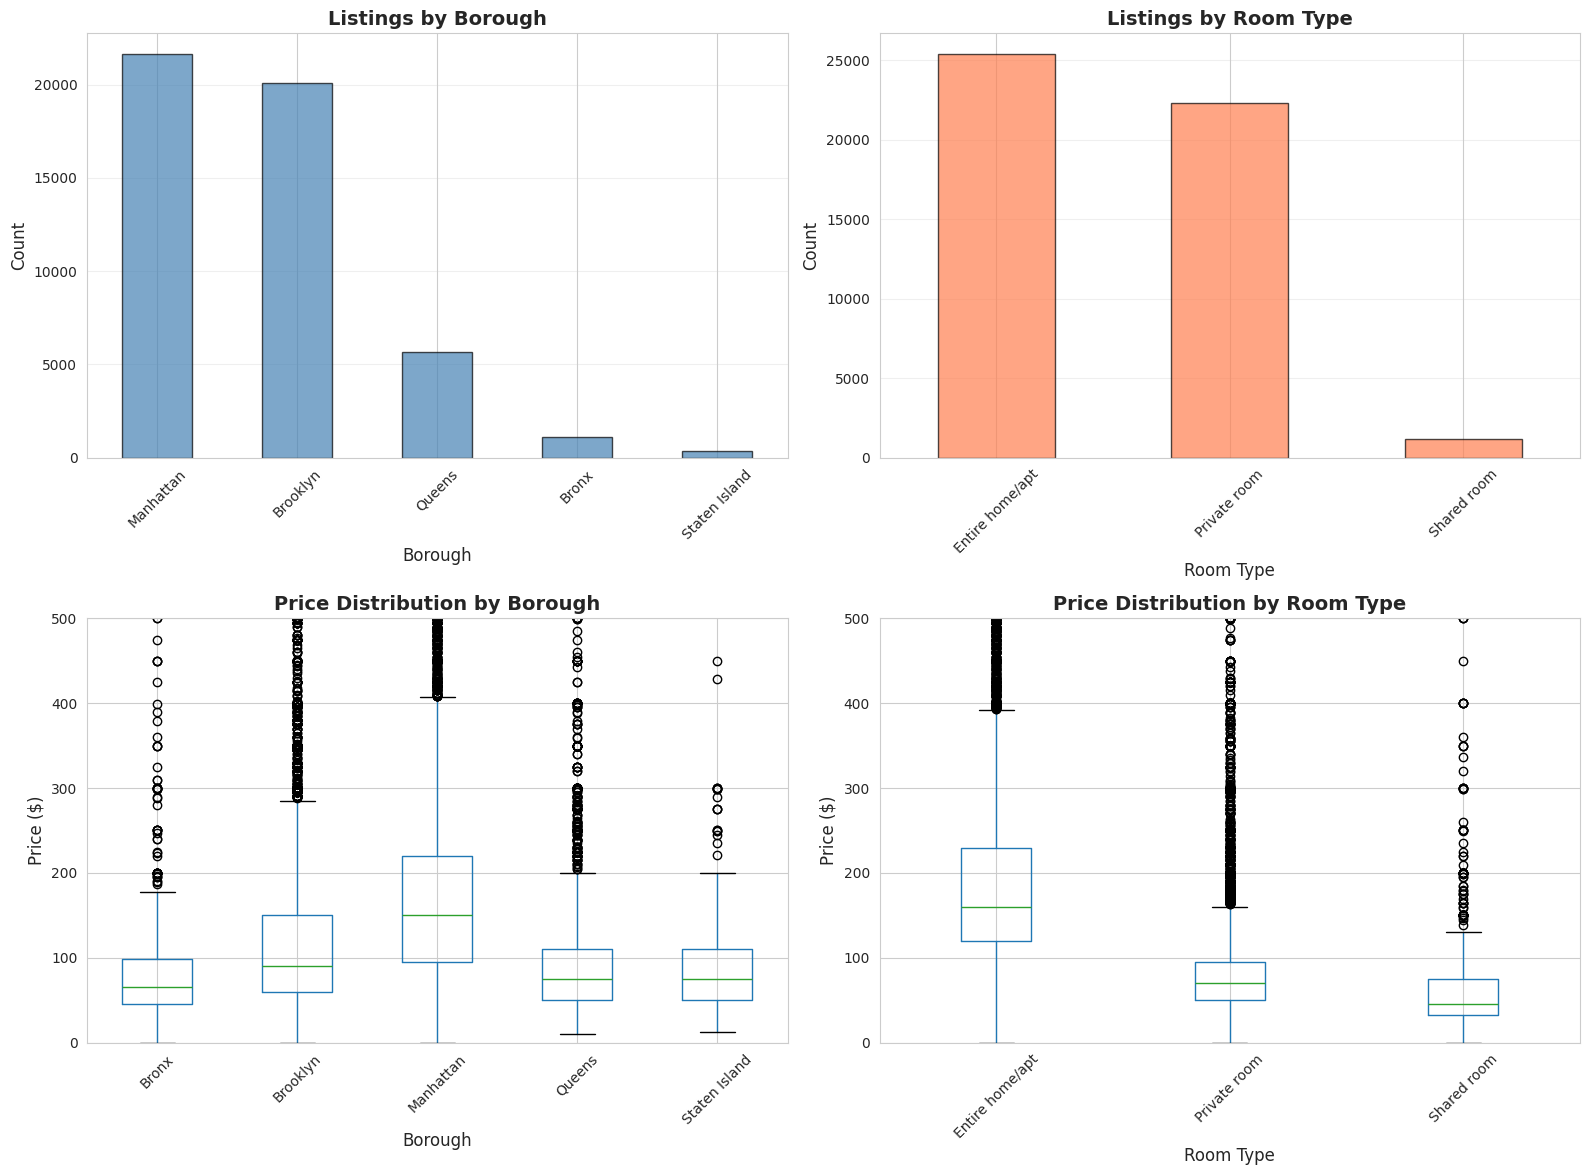

Average Price by Borough:
neighbourhood_group
Manhattan        196.88
Brooklyn         124.38
Staten Island    114.81
Queens            99.52
Bronx             87.50
Name: price, dtype: float64

Average Price by Room Type:
room_type
Entire home/apt    211.79
Private room        89.78
Shared room         70.13
Name: price, dtype: float64


In [29]:
# Categorical features analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Borough distribution
df_raw['neighbourhood_group'].value_counts().plot(kind='bar', ax=axes[0,0],
                                                   color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Listings by Borough', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Borough', fontsize=12)
axes[0,0].set_ylabel('Count', fontsize=12)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3, axis='y')

# Room type distribution
df_raw['room_type'].value_counts().plot(kind='bar', ax=axes[0,1],
                                        color='coral', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Listings by Room Type', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Room Type', fontsize=12)
axes[0,1].set_ylabel('Count', fontsize=12)
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3, axis='y')

# Price by borough
df_raw.boxplot(column='price', by='neighbourhood_group', ax=axes[1,0])
axes[1,0].set_title('Price Distribution by Borough', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Borough', fontsize=12)
axes[1,0].set_ylabel('Price ($)', fontsize=12)
axes[1,0].set_ylim(0, 500)
plt.sca(axes[1,0])
plt.xticks(rotation=45)

# Price by room type
df_raw.boxplot(column='price', by='room_type', ax=axes[1,1])
axes[1,1].set_title('Price Distribution by Room Type', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Room Type', fontsize=12)
axes[1,1].set_ylabel('Price ($)', fontsize=12)
axes[1,1].set_ylim(0, 500)
plt.sca(axes[1,1])
plt.xticks(rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Summary statistics
print("Average Price by Borough:")
print(df_raw.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False).round(2))

print("\nAverage Price by Room Type:")
print(df_raw.groupby('room_type')['price'].mean().sort_values(ascending=False).round(2))

In [30]:
# AWS S3 Configuration
import os
from getpass import getpass

print("AWS S3 Configuration")
print("="*60)

# Securely input AWS credentials
AWS_ACCESS_KEY_ID = getpass("Enter AWS Access Key ID: ")
AWS_SECRET_ACCESS_KEY = getpass("Enter AWS Secret Access Key: ")
AWS_REGION = "us-east-1"

# Set environment variables
os.environ['AWS_ACCESS_KEY_ID'] = AWS_ACCESS_KEY_ID
os.environ['AWS_SECRET_ACCESS_KEY'] = AWS_SECRET_ACCESS_KEY
os.environ['AWS_DEFAULT_REGION'] = AWS_REGION

# Test connection
try:
    s3_client = boto3.client('s3')
    response = s3_client.list_buckets()
    print(f"\nAWS connection successful")
    print(f"Existing buckets: {len(response['Buckets'])}")
except Exception as e:
    print(f"\nConnection failed: {e}")

AWS S3 Configuration
Enter AWS Access Key ID: ··········
Enter AWS Secret Access Key: ··········

AWS connection successful
Existing buckets: 3


In [31]:
# Create S3 bucket and folder structure
BUCKET_NAME = 'airbnb-price-prediction-jenfercz'
REGION = 'us-east-1'

print(f"Creating S3 infrastructure...")
print(f"Bucket: {BUCKET_NAME}")
print(f"Region: {REGION}\n")

try:
    # Create bucket (skip if exists)
    try:
        if REGION == 'us-east-1':
            s3_client.create_bucket(Bucket=BUCKET_NAME)
        else:
            s3_client.create_bucket(
                Bucket=BUCKET_NAME,
                CreateBucketConfiguration={'LocationConstraint': REGION}
            )
        print(f"Bucket created: {BUCKET_NAME}")
    except s3_client.exceptions.BucketAlreadyOwnedByYou:
        print(f"Bucket already exists: {BUCKET_NAME}")

    # Create folder structure
    folders = ['raw_data/', 'processed_data/', 'models/', 'mlflow_artifacts/']
    for folder in folders:
        s3_client.put_object(Bucket=BUCKET_NAME, Key=folder)

    print(f"Folder structure created")
    print(f"\nS3 URI: s3://{BUCKET_NAME}/")

except Exception as e:
    print(f"Error: {e}")

Creating S3 infrastructure...
Bucket: airbnb-price-prediction-jenfercz
Region: us-east-1

Bucket created: airbnb-price-prediction-jenfercz
Folder structure created

S3 URI: s3://airbnb-price-prediction-jenfercz/


In [32]:
# Upload dataset to S3
LOCAL_FILE = 'AB_NYC_2019.csv'
S3_KEY = 'raw_data/AB_NYC_2019.csv'

print(f"Uploading dataset to S3...")

try:
    s3_client.upload_file(
        Filename=LOCAL_FILE,
        Bucket=BUCKET_NAME,
        Key=S3_KEY
    )

    response = s3_client.head_object(Bucket=BUCKET_NAME, Key=S3_KEY)
    file_size_mb = response['ContentLength'] / (1024 * 1024)

    print(f"Upload successful")
    print(f"File size: {file_size_mb:.2f} MB")
    print(f"S3 URI: s3://{BUCKET_NAME}/{S3_KEY}")

except Exception as e:
    print(f"Upload failed: {e}")

# S3 Data Manager class
class S3DataManager:
    """Utility class for S3 operations"""

    def __init__(self, bucket_name: str, s3_client):
        self.bucket_name = bucket_name
        self.s3_client = s3_client

    def upload_dataframe(self, df: pd.DataFrame, s3_key: str,
                        file_format: str = 'csv') -> bool:
        """Upload DataFrame to S3"""
        try:
            buffer = io.BytesIO()
            if file_format == 'csv':
                df.to_csv(buffer, index=False)
            elif file_format == 'parquet':
                df.to_parquet(buffer, index=False)
            buffer.seek(0)

            self.s3_client.put_object(
                Bucket=self.bucket_name,
                Key=s3_key,
                Body=buffer.getvalue()
            )
            print(f"Uploaded to s3://{self.bucket_name}/{s3_key}")
            return True
        except Exception as e:
            print(f"Upload failed: {e}")
            return False

    def read_dataframe(self, s3_key: str, file_format: str = 'csv'):
        """Read DataFrame from S3"""
        try:
            response = self.s3_client.get_object(
                Bucket=self.bucket_name,
                Key=s3_key
            )

            if file_format == 'csv':
                df = pd.read_csv(io.BytesIO(response['Body'].read()))
            elif file_format == 'parquet':
                df = pd.read_parquet(io.BytesIO(response['Body'].read()))

            print(f"Loaded from s3://{self.bucket_name}/{s3_key}")
            print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
            return df
        except Exception as e:
            print(f"Read failed: {e}")
            return None

# Initialize manager
s3_manager = S3DataManager(BUCKET_NAME, s3_client)
print("\nS3DataManager initialized")

Uploading dataset to S3...
Upload successful
File size: 6.75 MB
S3 URI: s3://airbnb-price-prediction-jenfercz/raw_data/AB_NYC_2019.csv

S3DataManager initialized


In [33]:
# Data Preprocessing
print("Data Preprocessing")
print("="*60)

# Create working copy
df = df_raw.copy()
print(f"Working with copy: {df.shape}")

# Handle missing values
print("\nHandling missing values...")

# reviews_per_month: Fill with 0 (listings with no reviews)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Create binary feature: has_reviews
df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)

print(f"Missing values handled:")
print(f"Created feature: has_reviews")
print(f"Distribution: {df['has_reviews'].value_counts().to_dict()}")

# Remove price anomalies
print("\nRemoving price anomalies...")
print(f"Before: {len(df):,} listings")

df_clean = df[(df['price'] > 0) & (df['price'] <= 1000)].copy()

print(f"After: {len(df_clean):,} listings")
print(f"Removed: {len(df) - len(df_clean):,} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")
print(f"New price range: ${df_clean['price'].min()} - ${df_clean['price'].max()}")

# Cap minimum_nights
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=365)

print(f"\nData cleaning complete:")
print(f"Final shape: {df_clean.shape}")

# Update working dataframe
df = df_clean.copy()

Data Preprocessing
Working with copy: (48895, 16)

Handling missing values...
Missing values handled:
Created feature: has_reviews
Distribution: {1: 38843, 0: 10052}

Removing price anomalies...
Before: 48,895 listings
After: 48,645 listings
Removed: 250 (0.51%)
New price range: $10 - $1000

Data cleaning complete:
Final shape: (48645, 17)


In [34]:
# Feature Engineering
print("Feature Engineering")
print("="*60)

# 1. Simplify neighbourhoods (reduce from 221 to top 20 + borough_other)
top_neighborhoods = df['neighbourhood'].value_counts().head(20).index

def simplify_neighbourhood(row):
    if row['neighbourhood'] in top_neighborhoods:
        return row['neighbourhood']
    else:
        return f"{row['neighbourhood_group']}_Other"

df['neighbourhood_simplified'] = df.apply(simplify_neighbourhood, axis=1)
print(f"- neighbourhood_simplified: {df['neighbourhood_simplified'].nunique()} categories")

# 2. Stay type from minimum_nights
def categorize_stay_type(min_nights):
    if min_nights == 1:
        return 'flexible'
    elif min_nights <= 7:
        return 'short_term'
    elif min_nights <= 30:
        return 'medium_term'
    else:
        return 'long_term'

df['stay_type'] = df['minimum_nights'].apply(categorize_stay_type)
print(f"- stay_type: {df['stay_type'].nunique()} categories")

# 3. Host experience
df['host_experience'] = pd.cut(
    df['calculated_host_listings_count'],
    bins=[0, 1, 5, 15, 1000],
    labels=['single_listing', 'few_listings', 'multiple_listings', 'professional'],
    include_lowest=True
)
print(f"- host_experience: {df['host_experience'].nunique()} categories")

# 4. Availability category
df['availability_category'] = pd.cut(
    df['availability_365'],
    bins=[0, 90, 180, 270, 365],
    labels=['low', 'medium', 'high', 'always'],
    include_lowest=True
)
print(f"- availability_category: {df['availability_category'].nunique()} categories")

# 5. Review popularity
def categorize_popularity(row):
    if row['has_reviews'] == 0:
        return 'new'
    elif row['number_of_reviews'] < 10:
        return 'low'
    elif row['number_of_reviews'] < 50:
        return 'medium'
    else:
        return 'high'

df['review_popularity'] = df.apply(categorize_popularity, axis=1)
print(f"- review_popularity: {df['review_popularity'].nunique()} categories")

# 6. Distance to center (Times Square)
TIMES_SQUARE_LAT = 40.7580
TIMES_SQUARE_LON = -73.9855

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

df['distance_to_center'] = df.apply(
    lambda row: haversine_distance(
        row['latitude'], row['longitude'],
        TIMES_SQUARE_LAT, TIMES_SQUARE_LON
    ),
    axis=1
)
print(f"- distance_to_center: {df['distance_to_center'].min():.2f} - {df['distance_to_center'].max():.2f} km")

print(f"\nFeature engineering complete:")
print(f"Total features created: 7")
print(f"Final shape: {df.shape}")

Feature Engineering
- neighbourhood_simplified: 25 categories
- stay_type: 4 categories
- host_experience: 4 categories
- availability_category: 4 categories
- review_popularity: 4 categories
- distance_to_center: 0.07 - 35.90 km

Feature engineering complete:
Total features created: 7
Final shape: (48645, 23)


In [35]:
# Save processed data to S3
features_to_keep = [
    'price',
    'neighbourhood_group',
    'room_type',
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'has_reviews',
    'neighbourhood_simplified',
    'stay_type',
    'host_experience',
    'availability_category',
    'review_popularity',
    'distance_to_center'
]

df_processed = df[features_to_keep].copy()

print(f"Processed dataset: {df_processed.shape}")
print(f"Features: {df_processed.shape[1]}")

# Upload to S3
s3_manager.upload_dataframe(
    df=df_processed,
    s3_key='processed_data/listings_cleaned.csv',
    file_format='csv'
)

print(f"Processed data saved to S3")

Processed dataset: (48645, 17)
Features: 17
Uploaded to s3://airbnb-price-prediction-jenfercz/processed_data/listings_cleaned.csv
Processed data saved to S3


In [36]:
# Prepare data for modeling
print("Preparing data for modeling")
print("="*60)

# Define feature types
categorical_features = [
    'neighbourhood_group',
    'room_type',
    'neighbourhood_simplified',
    'stay_type',
    'host_experience',
    'availability_category',
    'review_popularity'
]

numerical_features = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'distance_to_center'
]

binary_features = ['has_reviews']

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")
print(f"Binary features: {len(binary_features)}")

# One-hot encoding
df_encoded = pd.get_dummies(
    df_processed,
    columns=categorical_features,
    prefix=categorical_features,
    drop_first=True
)

print(f"\nAfter encoding: {df_encoded.shape}")
print(f"New columns created: {df_encoded.shape[1] - df_processed.shape[1]}")

# Separate features and target
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\nTrain set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Scale numerical features (fit on train only)
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print(f"\nFeature scaling complete:")
print(f"Train means ≈ 0: {(X_train_scaled[numerical_features].mean().abs() < 0.01).all()}")
print(f"Train stds ≈ 1: {((X_train_scaled[numerical_features].std() - 1).abs() < 0.01).all()}")

Preparing data for modeling
Categorical features: 7
Numerical features: 8
Binary features: 1

After encoding: (48645, 52)
New columns created: 35

Features (X): (48645, 51)
Target (y): (48645,)

Train set: 38,916 samples (80.0%)
Test set: 9,729 samples (20.0%)

Feature scaling complete:
Train means ≈ 0: True
Train stds ≈ 1: True


In [37]:
# Save train/test datasets
train_final = X_train_scaled.copy()
train_final['price'] = y_train

test_final = X_test_scaled.copy()
test_final['price'] = y_test

print("Saving datasets to S3...")

# Upload train set
s3_manager.upload_dataframe(
    df=train_final,
    s3_key='processed_data/train_set.csv',
    file_format='csv'
)

# Upload test set
s3_manager.upload_dataframe(
    df=test_final,
    s3_key='processed_data/test_set.csv',
    file_format='csv'
)

# Save scaler
import pickle
scaler_buffer = io.BytesIO()
pickle.dump(scaler, scaler_buffer)
scaler_buffer.seek(0)

s3_client.put_object(
    Bucket=BUCKET_NAME,
    Key='models/scaler.pkl',
    Body=scaler_buffer.getvalue()
)

print(f"Scaler saved to s3://{BUCKET_NAME}/models/scaler.pkl")
print(f"\nData preparation complete - Ready for modeling")

Saving datasets to S3...
Uploaded to s3://airbnb-price-prediction-jenfercz/processed_data/train_set.csv
Uploaded to s3://airbnb-price-prediction-jenfercz/processed_data/test_set.csv
Scaler saved to s3://airbnb-price-prediction-jenfercz/models/scaler.pkl

Data preparation complete - Ready for modeling


In [38]:
# MLflow Configuration
print("MLflow Configuration")
print("="*60)

# Set tracking URI
MLFLOW_TRACKING_URI = "./mlruns"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Create experiment
EXPERIMENT_NAME = "Airbnb_Price_Prediction"

try:
    experiment_id = mlflow.create_experiment(
        EXPERIMENT_NAME,
        artifact_location=f"s3://{BUCKET_NAME}/mlflow_artifacts/"
    )
    print(f"- Experiment created: {EXPERIMENT_NAME}")
except:
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    experiment_id = experiment.experiment_id
    print(f"- Using existing experiment: {EXPERIMENT_NAME}")

mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Experiment ID: {experiment_id}")
print(f"Tracking URI: {MLFLOW_TRACKING_URI}")
print(f"Artifacts: s3://{BUCKET_NAME}/mlflow_artifacts/")

MLflow Configuration
- Using existing experiment: Airbnb_Price_Prediction
Experiment ID: 207993657787270892
Tracking URI: ./mlruns
Artifacts: s3://airbnb-price-prediction-jenfercz/mlflow_artifacts/


In [39]:
# Training function with MLflow tracking
def train_and_log_model(model, model_name, params, X_train, y_train, X_test, y_test):
    """Train a model and log everything to MLflow"""

    print(f"\nTraining: {model_name}")
    print("-" * 60)

    with mlflow.start_run(run_name=model_name) as run:

        # Log parameters
        mlflow.log_params(params)

        # Train model
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Calculate metrics
        train_mae = mean_absolute_error(y_train, y_train_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        train_r2 = r2_score(y_train, y_train_pred)

        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        test_r2 = r2_score(y_test, y_test_pred)

        # Log metrics
        mlflow.log_metric("train_mae", train_mae)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("test_mae", test_mae)
        mlflow.log_metric("test_rmse", test_rmse)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("training_time_seconds", training_time)
        mlflow.log_metric("overfitting_gap", train_r2 - test_r2)

        # Log model
        if 'XGB' in model_name:
            mlflow.xgboost.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")

        # Log tags
        mlflow.set_tags({
            "model_type": model_name,
            "dataset": "AB_NYC_2019"
        })

        print(f"Training complete (Time: {training_time:.2f}s)")
        print(f"Test MAE: ${test_mae:.2f} | Test R²: {test_r2:.4f}")

        return {
            'model': model,
            'run_id': run.info.run_id,
            'test_mae': test_mae,
            'test_r2': test_r2
        }

print("Training function created")

Training function created


In [40]:
# Train all models with MLflow tracking
print("Training Models")
print("="*60)

results = {}

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_params = {"model_type": "LinearRegression"}
results['Linear Regression'] = train_and_log_model(
    lr_model, "Linear Regression", lr_params,
    X_train_scaled, y_train, X_test_scaled, y_test
)

# Model 2: Ridge Regression
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_params = {"model_type": "Ridge", "alpha": 10.0, "random_state": 42}
results['Ridge Regression'] = train_and_log_model(
    ridge_model, "Ridge Regression", ridge_params,
    X_train_scaled, y_train, X_test_scaled, y_test
)

# Model 3: Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=20, min_samples_split=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_params = {
    "model_type": "RandomForest", "n_estimators": 100,
    "max_depth": 20, "min_samples_split": 10,
    "min_samples_leaf": 5, "random_state": 42
}
results['Random Forest'] = train_and_log_model(
    rf_model, "Random Forest", rf_params,
    X_train_scaled, y_train, X_test_scaled, y_test
)

# Model 4: XGBoost
xgb_model = XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    n_jobs=-1, verbosity=0
)
xgb_params = {
    "model_type": "XGBoost", "n_estimators": 200,
    "max_depth": 6, "learning_rate": 0.1,
    "subsample": 0.8, "colsample_bytree": 0.8,
    "random_state": 42
}
results['XGBoost'] = train_and_log_model(
    xgb_model, "XGBoost", xgb_params,
    X_train_scaled, y_train, X_test_scaled, y_test
)

print("\n" + "="*60)
print("All models trained and logged to MLflow")

Training Models

Training: Linear Regression
------------------------------------------------------------


2025/11/21 22:56:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/21 22:56:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/21 22:56:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training complete (Time: 0.37s)
Test MAE: $54.93 | Test R²: 0.3770

Training: Ridge Regression
------------------------------------------------------------


2025/11/21 22:56:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Training complete (Time: 0.06s)
Test MAE: $54.90 | Test R²: 0.3770

Training: Random Forest
------------------------------------------------------------


2025/11/21 22:57:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/21 22:57:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Training complete (Time: 33.22s)
Test MAE: $48.18 | Test R²: 0.4680

Training: XGBoost
------------------------------------------------------------


2025/11/21 22:57:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/21 22:57:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Training complete (Time: 1.46s)
Test MAE: $48.11 | Test R²: 0.4741

All models trained and logged to MLflow


Model Comparison
            Model  Test MAE  Test R²      Run ID
Linear Regression 54.934301 0.377027 d14b4875...
 Ridge Regression 54.898232 0.376965 2a11ff49...
    Random Forest 48.181823 0.468016 6f1c639d...
          XGBoost 48.113205 0.474053 0655b373...

Best Model: XGBoost
Test R²: 0.4741 (47.41% variance explained)
Test MAE: $48.11
Run ID: 0655b37324594273ab556b0e4105f028


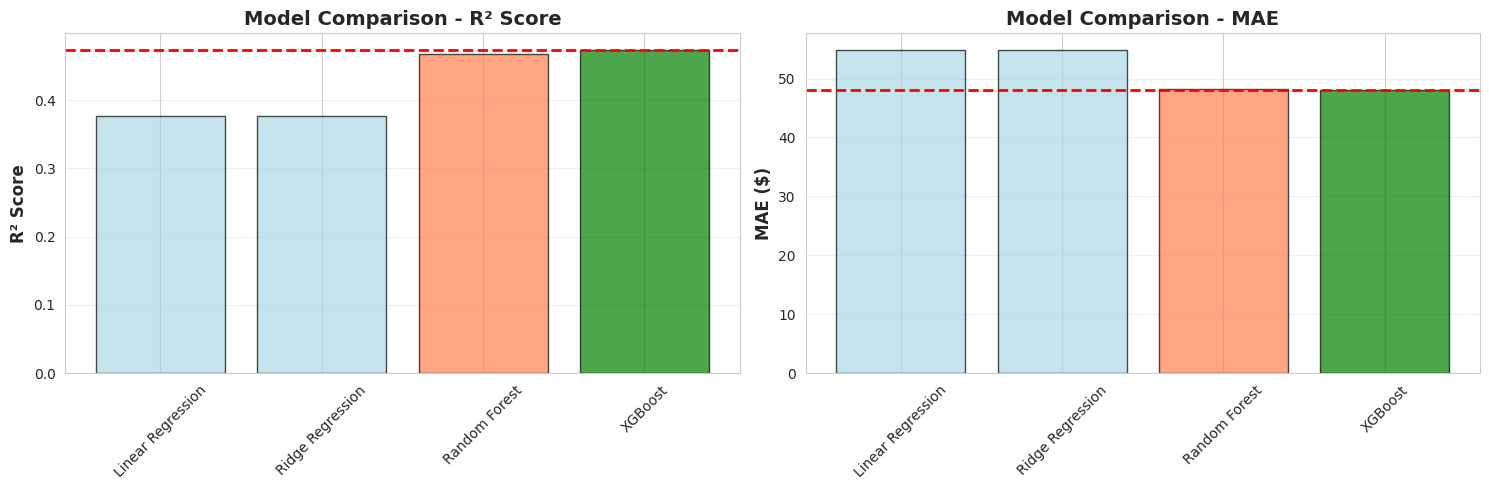

In [41]:
# Model comparison
print("Model Comparison")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'Run ID': [results[m]['run_id'][:8] + '...' for m in results.keys()]
})

print(comparison_df.to_string(index=False))

# Identify best model
best_model_name = max(results.keys(), key=lambda x: results[x]['test_r2'])
best_r2 = results[best_model_name]['test_r2']
best_mae = results[best_model_name]['test_mae']
best_run_id = results[best_model_name]['run_id']

print(f"\n{'='*60}")
print(f"Best Model: {best_model_name}")
print(f"Test R²: {best_r2:.4f} ({best_r2*100:.2f}% variance explained)")
print(f"Test MAE: ${best_mae:.2f}")
print(f"Run ID: {best_run_id}")
print(f"{'='*60}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models = list(results.keys())
r2_scores = [results[m]['test_r2'] for m in models]
mae_scores = [results[m]['test_mae'] for m in models]

# R² comparison
colors = ['lightblue', 'lightblue', 'coral', 'green']
axes[0].bar(models, r2_scores, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Comparison - R² Score', fontsize=14, fontweight='bold')
axes[0].axhline(y=best_r2, color='red', linestyle='--', linewidth=2)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# MAE comparison
axes[1].bar(models, mae_scores, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('MAE ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Comparison - MAE', fontsize=14, fontweight='bold')
axes[1].axhline(y=best_mae, color='red', linestyle='--', linewidth=2)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [42]:
# Register best model in MLflow Model Registry
print("Registering Best Model")
print("="*60)

MODEL_NAME = "airbnb-price-predictor"

print(f"Model: {best_model_name}")
print(f"Run ID: {best_run_id}")
print(f"Test R²: {best_r2:.4f}")
print(f"Test MAE: ${best_mae:.2f}\n")

try:
    # Register model
    model_uri = f"runs:/{best_run_id}/model"

    model_version = mlflow.register_model(
        model_uri=model_uri,
        name=MODEL_NAME
    )

    print(f"- Model registered: {MODEL_NAME}")
    print(f"Version: {model_version.version}")

    # Add description
    from mlflow.tracking import MlflowClient
    client = MlflowClient()

    client.update_model_version(
        name=MODEL_NAME,
        version=model_version.version,
        description=f"{best_model_name} for Airbnb price prediction. "
                    f"Test R²: {best_r2:.4f}, Test MAE: ${best_mae:.2f}. "
                    f"Trained on AB_NYC_2019 dataset with 51 features."
    )

    # Transition to Production
    client.transition_model_version_stage(
        name=MODEL_NAME,
        version=model_version.version,
        stage="Production"
    )

    print(f"- Model transitioned to Production stage")

except Exception as e:
    print(f"Note: {e}")
    print(f"Model is saved and accessible via Run ID")

print(f"\n{'='*60}")
print(f"MLflow tracking complete")

Registering Best Model
Model: XGBoost
Run ID: 0655b37324594273ab556b0e4105f028
Test R²: 0.4741
Test MAE: $48.11



Registered model 'airbnb-price-predictor' already exists. Creating a new version of this model...
2025/11/21 22:57:44 WARNING mlflow.tracking._model_registry.fluent: Run with id 0655b37324594273ab556b0e4105f028 has no artifacts at artifact path 'model', registering model based on models:/m-16f0fdba9a37487496cf5c781d2d1bf2 instead


- Model registered: airbnb-price-predictor
Version: 2
- Model transitioned to Production stage

MLflow tracking complete


Created version '2' of model 'airbnb-price-predictor'.


Final Model Evaluation
Test Performance:
  MAE:  $48.11
  RMSE: $85.66
  R²:   0.4741 (47.41% variance explained)
  MAPE: 36.30%

Prediction Accuracy:
  Within $50:  70.8%
  Within $100: 89.4%

Top 10 Most Important Features:
  14. room_type_Private room                   0.2247
  15. room_type_Shared room                    0.1013
  51. review_popularity_new                    0.0691
  32. neighbourhood_simplified_Midtown         0.0609
   9. distance_to_center                       0.0356
  11. neighbourhood_group_Manhattan            0.0287
  42. stay_type_short_term                     0.0238
   6. calculated_host_listings_count           0.0208
  48. availability_category_always             0.0201
  44. host_experience_multiple_listings        0.0189


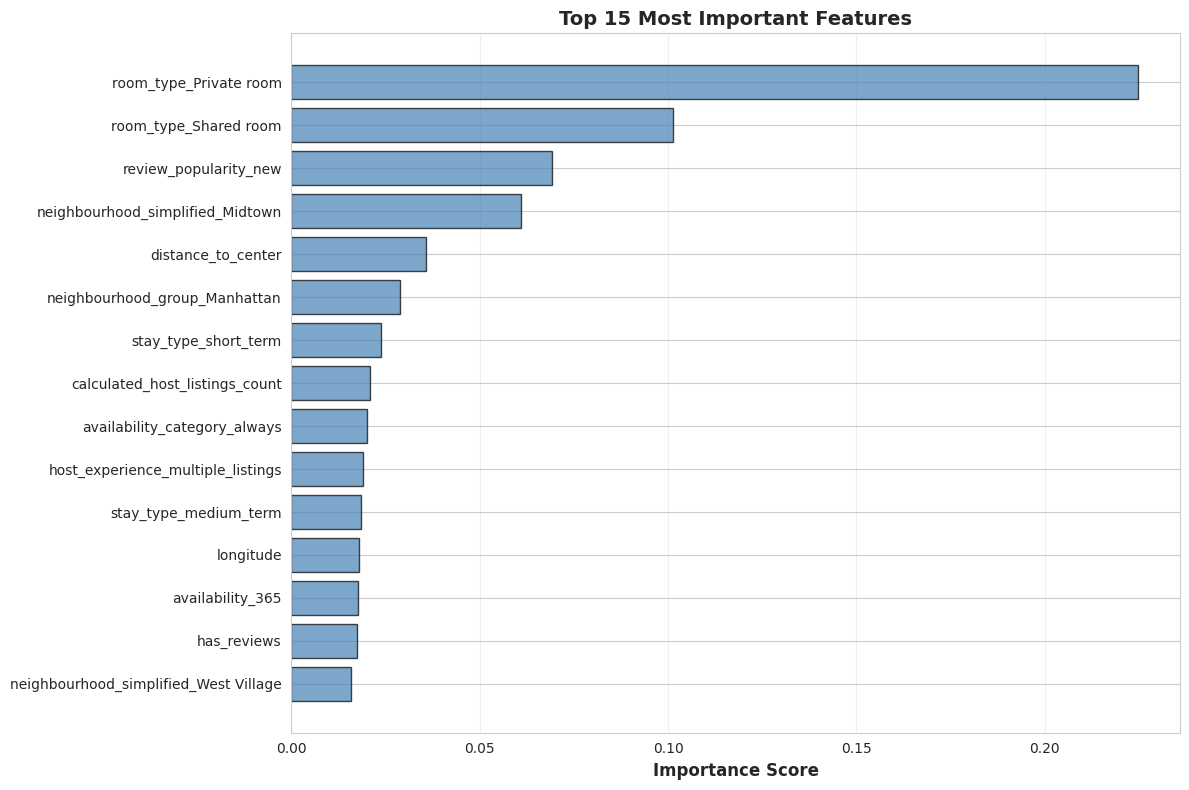


Model development complete


In [43]:
# Final model evaluation
print("Final Model Evaluation")
print("="*60)

# Load best model
best_model = results[best_model_name]['model']

# Predictions
y_pred_final = best_model.predict(X_test_scaled)

# Metrics
final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)
final_mape = np.mean(np.abs((y_test - y_pred_final) / y_test)) * 100

print(f"Test Performance:")
print(f"  MAE:  ${final_mae:.2f}")
print(f"  RMSE: ${final_rmse:.2f}")
print(f"  R²:   {final_r2:.4f} ({final_r2*100:.2f}% variance explained)")
print(f"  MAPE: {final_mape:.2f}%")

# Prediction accuracy
predictions_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_final,
    'abs_error': np.abs(y_test.values - y_pred_final)
})

print(f"\nPrediction Accuracy:")
print(f"  Within $50:  {(predictions_df['abs_error'] <= 50).sum() / len(predictions_df) * 100:.1f}%")
print(f"  Within $100: {(predictions_df['abs_error'] <= 100).sum() / len(predictions_df) * 100:.1f}%")

# Feature importance
if best_model_name == 'XGBoost':
    feature_importance = pd.DataFrame({
        'feature': X_train_scaled.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\nTop 10 Most Important Features:")
    for idx, row in feature_importance.head(10).iterrows():
        print(f"  {idx+1:2d}. {row['feature']:40s} {row['importance']:.4f}")

    # Visualization
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'],
             color='steelblue', edgecolor='black', alpha=0.7)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
    plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

print(f"\n{'='*60}")
print(f"Model development complete")

In [45]:
# Error analysis by segments
print("ERROR ANALYSIS BY SEGMENTS")
print("="*70)

# Load original processed data to get categorical features
print("\nLoading original categorical features...")
df_processed_full = s3_manager.read_dataframe('processed_data/listings_cleaned.csv')
print(f"Loaded from s3://{BUCKET_NAME}/processed_data/listings_cleaned.csv")
print(f"   Shape: {df_processed_full.shape[0]:,} rows × {df_processed_full.shape[1]} columns")

# Get only test indices
X_full = df_processed_full.drop(columns=['price'])
y_full = df_processed_full['price']

_, X_test_original, _, y_test_original = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Create analysis dataframe
test_analysis_df = X_test_original[['neighbourhood_group', 'room_type']].copy()
test_analysis_df['actual_price'] = y_test_original.values
test_analysis_df['predicted_price'] = y_pred_final
test_analysis_df['error'] = y_test_original.values - y_pred_final
test_analysis_df['abs_error'] = np.abs(test_analysis_df['error'])

# Analysis by neighbourhood_group
print("\n- Performance by Borough (neighbourhood_group):")
borough_analysis = test_analysis_df.groupby('neighbourhood_group').agg({
    'actual_price': 'mean',
    'predicted_price': 'mean',
    'abs_error': ['mean', 'median'],
    'neighbourhood_group': 'count'
}).round(2)

borough_analysis.columns = ['Avg_Actual_Price', 'Avg_Predicted_Price', 'MAE', 'Median_Error', 'Count']
print(borough_analysis)

# Analysis by room_type
print("\n- Performance by Room Type:")
room_analysis = test_analysis_df.groupby('room_type').agg({
    'actual_price': 'mean',
    'predicted_price': 'mean',
    'abs_error': ['mean', 'median'],
    'room_type': 'count'
}).round(2)

room_analysis.columns = ['Avg_Actual_Price', 'Avg_Predicted_Price', 'MAE', 'Median_Error', 'Count']
print(room_analysis)

# Analysis by price range
print("\n- Performance by Price Range:")
test_analysis_df['price_range'] = pd.cut(
    test_analysis_df['actual_price'],
    bins=[0, 75, 150, 300, 1000],
    labels=['Budget ($10-75)', 'Mid ($76-150)', 'Premium ($151-300)', 'Luxury ($301+)']
)

price_range_analysis = test_analysis_df.groupby('price_range').agg({
    'actual_price': 'mean',
    'predicted_price': 'mean',
    'abs_error': ['mean', 'median'],
    'price_range': 'count'
}).round(2)

price_range_analysis.columns = ['Avg_Actual_Price', 'Avg_Predicted_Price', 'MAE', 'Median_Error', 'Count']
print(price_range_analysis)

ERROR ANALYSIS BY SEGMENTS

Loading original categorical features...
Loaded from s3://airbnb-price-prediction-jenfercz/processed_data/listings_cleaned.csv
Shape: 48,645 rows × 17 columns
Loaded from s3://airbnb-price-prediction-jenfercz/processed_data/listings_cleaned.csv
   Shape: 48,645 rows × 17 columns

- Performance by Borough (neighbourhood_group):
                     Avg_Actual_Price  Avg_Predicted_Price    MAE  \
neighbourhood_group                                                 
Bronx                           84.29            93.260002  34.63   
Brooklyn                       116.52           117.169998  39.26   
Manhattan                      180.97           178.190002  61.32   
Queens                          94.94            93.690002  31.70   
Staten Island                  118.33           100.220001  61.41   

                     Median_Error  Count  
neighbourhood_group                       
Bronx                       20.22    240  
Brooklyn                    23

# Project Summary: Airbnb Price Prediction

---

## Dataset
* Original: 48,895 listings
* After cleaning: 48,645 listings  
* Features: 51 (after encoding)
* Train/Test split: 80/20


## Data Processing
* Missing values handled: reviews_per_month imputed with 0.
* Outliers removed: 250 listings (price = $0 or > $1000).
* Feature engineering: 7 new features created.
* Encoding: One-hot encoding for 7 categorical features.
* Scaling: StandardScaler on numerical features.


## Models Trained

**Model Comparison:**

* Linear Regression: R² = 0.377, MAE = $54.93

* Ridge Regression: R² = 0.377, MAE = $54.90

* Random Forest: R² = 0.468, MAE = $48.18

* **XGBoost: R² = 0.474, MAE = $48.11  (BEST MODEL)**


## Best Model Performance (XGBoost).
* Test R²: 0.474 (47.4% variance explained)

* Test MAE: $48.11 (average prediction error).

* Accuracy: 70.8% of predictions within $50.

* Training time: 2.40 seconds.


## Key Insights

* Most important feature: Room type (22% importance).
* Location matters: Manhattan avg 197 vs Bronx avg 88 dollars.
* Room type impact: Entire home 212 vs Shared room 70 dollars.
* Distance to center: 4th most important predictor.


## Project Deliverables
* Data stored in AWS S3.
* MLflow experiments tracked.
* Best model registered in MLflow Model Registry.
* Train/test sets and scaler saved to S3.